<a href="https://colab.research.google.com/github/DChristianls/Archives/blob/main/Ex2_M2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

P(X = 9) = 0.2684 (26.84%)
P(X >= 8) = 0.6778 (67.78%)


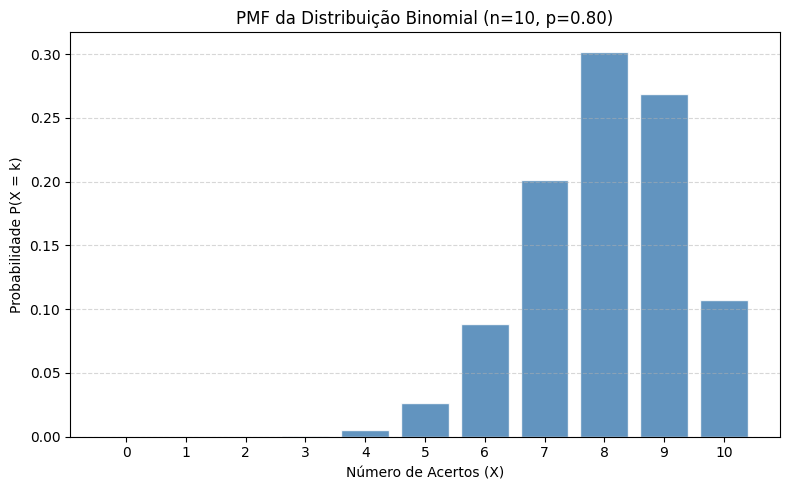

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parâmetros: n = total de tentativas, p = probabilidade de sucesso (acerto)
n, p = 10, 0.80

# (a-i) Probabilidade de acertar EXATAMENTE 9 em 10 sinistros
# Usamos a PMF para o valor exato 9
prob_exato_9 = binom.pmf(9, n, p)
print(f"P(X = 9) = {prob_exato_9:.4f} ({prob_exato_9:.2%})")

# (a-ii) Probabilidade de acertar PELO MENOS 8 em 10 sinistros
# "Pelo menos 8" significa 8, 9 ou 10.
# Usamos o complemento: 1 - P(X <= 7) usando a CDF
prob_8_ou_mais = 1 - binom.cdf(7, n, p)
print(f"P(X >= 8) = {prob_8_ou_mais:.4f} ({prob_8_ou_mais:.2%})")

# (a-iii) Plotar a PMF completa (todos os valores de X de 0 a 10)
valores_x = np.arange(0, 11)
# Passamos o array de valores para calcular a probabilidade de cada um de uma vez
pmf = binom.pmf(valores_x, n, p)

# Configuração do gráfico
plt.figure(figsize=(8, 5))
plt.bar(valores_x, pmf, color='steelblue', edgecolor='white', alpha=0.85)
plt.xlabel('Número de Acertos (X)')
plt.ylabel('Probabilidade P(X = k)')
plt.title('PMF da Distribuição Binomial (n=10, p=0.80)')
plt.xticks(valores_x)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Media teorica ( qualquer n): US$ 13270.42
Erro-padrao para n=30:                  US$  2210.98


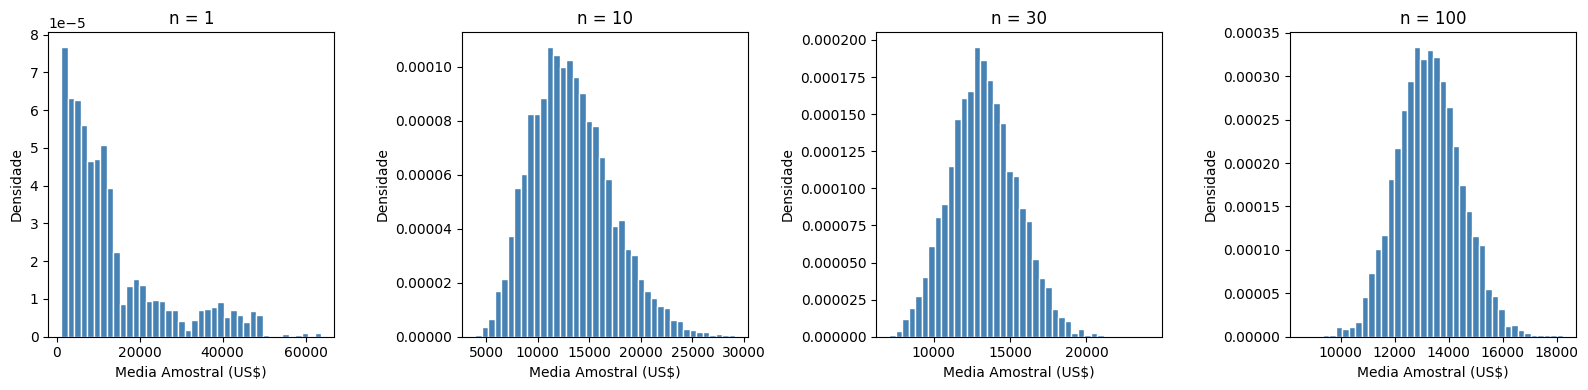

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Correção da URL (removendo os espaços internos)
url = (
    'https://raw.githubusercontent.com/stedy/'
    'Machine-Learning-with-R-datasets/master/insurance.csv'
)
df = pd.read_csv(url)

np.random.seed(42)
n_sim = 5000
tamanhos = [1, 10, 30, 100]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, n in enumerate(tamanhos):
    # (a-i) Gere n_sim medias amostrais, cada uma calculada sobre n observacoes
    # Usamos o método .sample com reposição (replace=True) para simular as amostras
    medias = [df['charges'].sample(n, replace=True).mean() for _ in range(n_sim)]

    axes[i].hist(medias, bins=40, color='steelblue', edgecolor='white', density=True)
    axes[i].set_title(f'n = {n}')
    axes[i].set_xlabel('Media Amostral (US$)')
    axes[i].set_ylabel('Densidade')

# (a-ii) Calcule a media teorica e o erro-padrao para n = 30
# A média teórica das médias amostrais é a própria média da população (mu)
mu_charges = df['charges'].mean()

# O erro-padrão (SE) é o desvio padrão da população dividido pela raiz quadrada de n
se_n30 = df['charges'].std() / np.sqrt(30)

print(f"Media teorica ( qualquer n): US$ {mu_charges:.2f}")
print(f"Erro-padrao para n=30:                  US$  {se_n30:.2f}")

plt.tight_layout()
plt.show()